<a href="https://colab.research.google.com/github/ifrah123781/DecodeLabs-Project-4-Data-Visualization/blob/main/DecodeLabs_Project_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Step # 1: Import Libraries & Load DataSet

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
import io

# visual style setup
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

# upload dataset
uploaded = files.upload()

# get the uploaded file name dynamically
file_name = list(uploaded.keys())[0]

# read the excel file directly from memory
df = pd.read_excel(io.BytesIO(uploaded[file_name]))

print(f"\n'{file_name}' loaded successfully! Total records: {len(df)}")
df.head()

Saving Dataset for Data Analytics (3).xlsx to Dataset for Data Analytics (3).xlsx

'Dataset for Data Analytics (3).xlsx' loaded successfully! Total records: 1200


,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


Step # 2: Productive Revenue (Bar Chart)

/tmp/ipykernel_512/1465574711.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bar_plot = sns.barplot(data=product_revenue, x="Product", y="TotalPrice", palette="viridis")


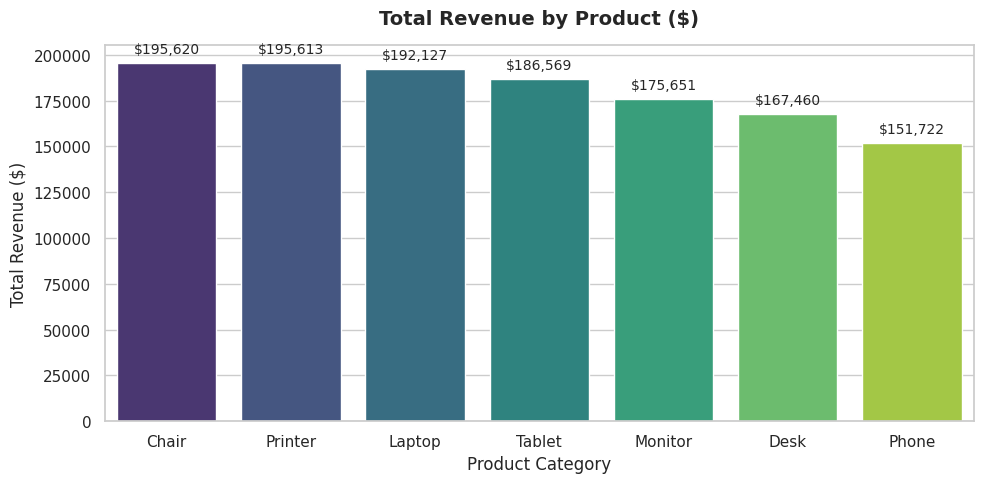

In [6]:
product_revenue = df.groupby("Product")["TotalPrice"].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(10, 5))
bar_plot = sns.barplot(data=product_revenue, x="Product", y="TotalPrice", palette="viridis")

plt.title("Total Revenue by Product ($)", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Product Category", fontsize=12)
plt.ylabel("Total Revenue ($)", fontsize=12)

# Display exact revenue on top of each bar
for p in bar_plot.patches:
    bar_plot.annotate(f"${p.get_height():,.0f}",
                      (p.get_x() + p.get_width() / 2., p.get_height()),
                      ha='center', va='bottom', fontsize=10, xytext=(0, 5),
                      textcoords='offset points')

plt.tight_layout()
plt.show()

Step # 3: Monthly Revenue Trend (Line Chart)

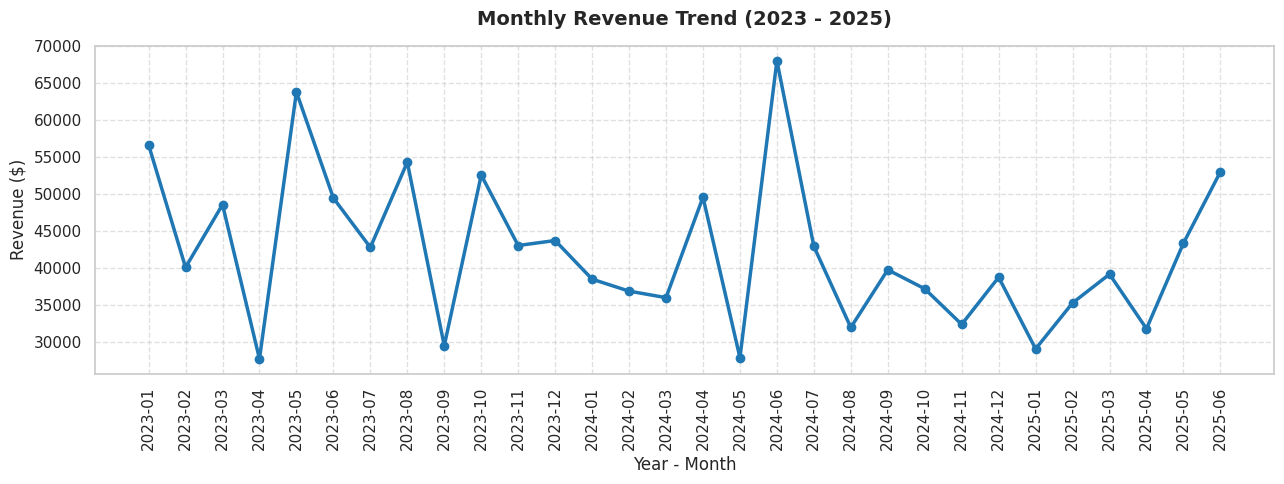

In [11]:
# Ensure Date is datetime and extract YearMonth
df["Date"] = pd.to_datetime(df["Date"])
df["YearMonth"] = df["Date"].dt.to_period("M").astype(str)

monthly_trend = df.groupby("YearMonth")["TotalPrice"].sum().reset_index()

plt.figure(figsize=(13, 5))
plt.plot(monthly_trend["YearMonth"], monthly_trend["TotalPrice"], marker="o", color="#1f77b4", linewidth=2.5)

plt.title("Monthly Revenue Trend (2023 - 2025)", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Year - Month", fontsize=12)
plt.ylabel("Revenue ($)", fontsize=12)
plt.xticks(rotation=90)
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

Step # 4: Order Status Distribution (Pie / Donut Chart)

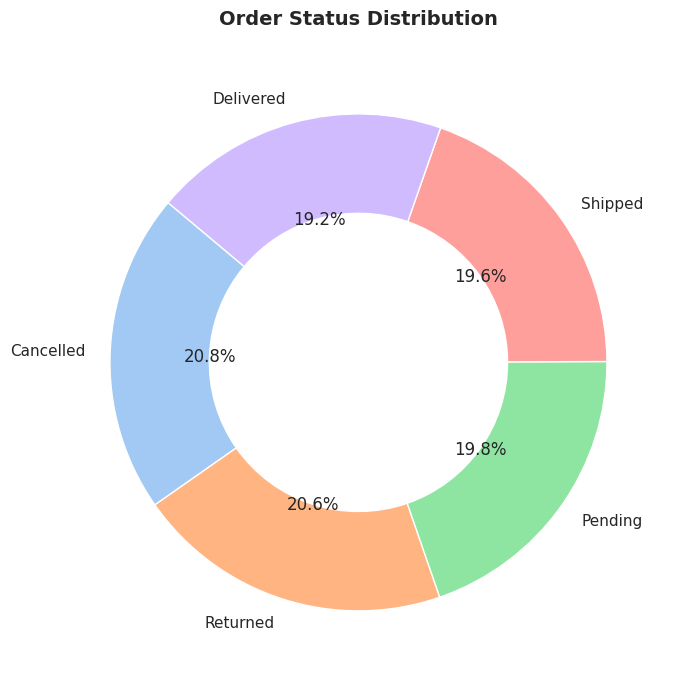

In [13]:
status_counts = df["OrderStatus"].value_counts()
colors = sns.color_palette("pastel")[0:len(status_counts)]

plt.figure(figsize=(7, 7))
plt.pie(status_counts, labels=status_counts.index, autopct="%1.1f%%", startangle=140,
        colors=colors, wedgeprops=dict(width=0.4, edgecolor='w'))

plt.title("Order Status Distribution", fontsize=14, fontweight="bold", pad=20)
plt.tight_layout()
plt.show()


Step # 5: Revenue By Marketing / Referral Channel (Horizontal Bar Chart)

/tmp/ipykernel_512/268457544.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  bar_h = sns.barplot(data=referral_revenue, y="ReferralSource", x="TotalPrice", palette="magma")


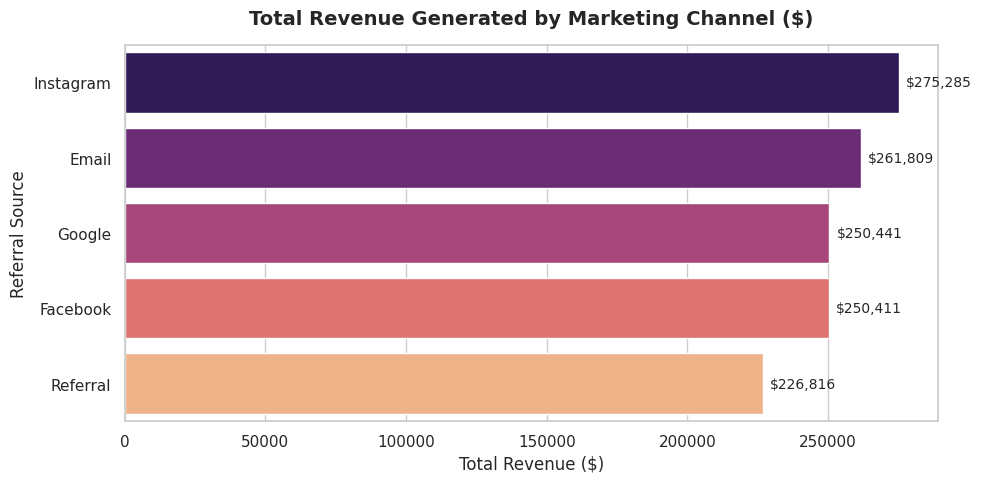

In [15]:
referral_revenue = df.groupby("ReferralSource")["TotalPrice"].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(10, 5))
bar_h = sns.barplot(data=referral_revenue, y="ReferralSource", x="TotalPrice", palette="magma")

plt.title("Total Revenue Generated by Marketing Channel ($)", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Total Revenue ($)", fontsize=12)
plt.ylabel("Referral Source", fontsize=12)

# Value annotations on each bar
for p in bar_h.patches:
    width = p.get_width()
    bar_h.annotate(f"${width:,.0f}",
                   (width, p.get_y() + p.get_height() / 2.),
                   ha='left', va='center', fontsize=10, xytext=(5, 0),
                   textcoords='offset points')

plt.tight_layout()
plt.show()

Step # 6: Payment Methods Comparison (Bar Chart)

/tmp/ipykernel_512/3696064401.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bar_pay = sns.barplot(data=payment_stats, x="PaymentMethod", y="TransactionCount", palette="crest")


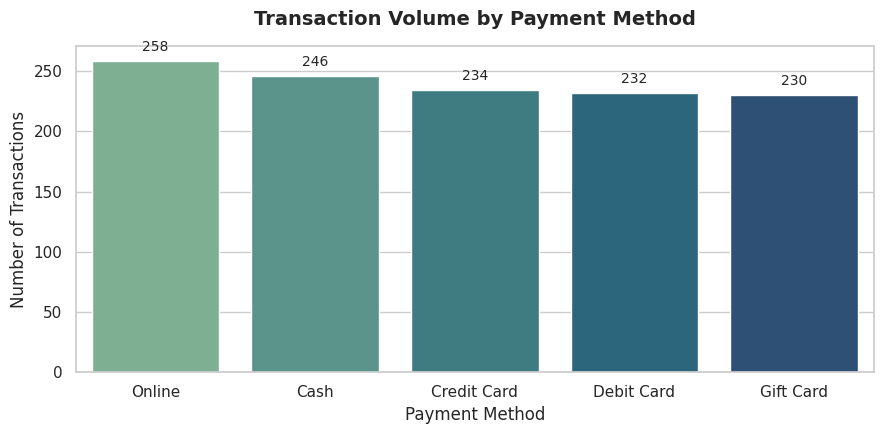

In [16]:
payment_stats = df.groupby("PaymentMethod")["OrderID"].count().sort_values(ascending=False).reset_index()
payment_stats.columns = ["PaymentMethod", "TransactionCount"]

plt.figure(figsize=(9, 4.5))
bar_pay = sns.barplot(data=payment_stats, x="PaymentMethod", y="TransactionCount", palette="crest")

plt.title("Transaction Volume by Payment Method", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Payment Method", fontsize=12)
plt.ylabel("Number of Transactions", fontsize=12)

# Value annotations on top of each bar
for p in bar_pay.patches:
    bar_pay.annotate(f"{int(p.get_height())}",
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=10, xytext=(0, 5),
                     textcoords='offset points')

plt.tight_layout()
plt.show()